<a href="https://colab.research.google.com/github/Jachy47/Vitak2/blob/main/NoveMytoStreetsmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install osmnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.4 MB/s eta 0:00:00


In [3]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

Délka: 1990 m,  uzlů: 19


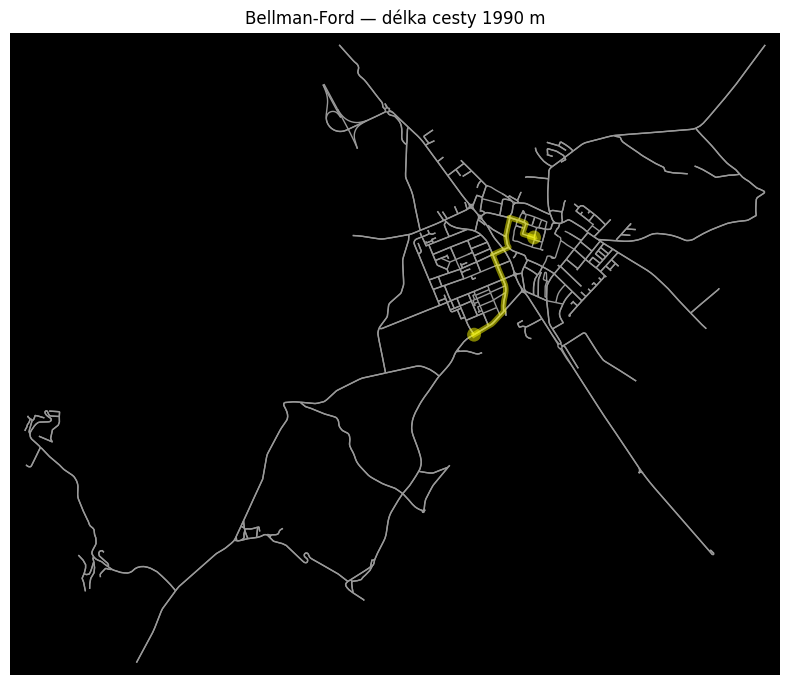

In [11]:
G = ox.graph_from_place("Vysoké Mýto, Czech Republic", network_type="drive",simplify=True) # zrusim multigraf
# ── 2. BELLMAN-FORD OD NULY ────────────────────────────────────────
def bellman_ford(graf, start, cil):
    uzly = list(graf.nodes)
    hrany = [(u, v, d["length"]) for u, v, d in graf.edges(data=True)]

    # Vzdálenosti — na začátku vše nekonečno
    dist = {u: float("inf") for u in uzly}
    dist[start] = 0
    odkud = {u: None for u in uzly}

    # Klíčová myšlenka: opakuj (počet uzlů - 1) krát
    for _ in range(len(uzly) - 1):
        zmenilo_se = False
        for u, v, vaha in hrany:          # projdi VŠECHNY hrany
            if dist[u] + vaha < dist[v]:  # lze zlepšit?
                dist[v] = dist[u] + vaha
                odkud[v] = u
                zmenilo_se = True
        if not zmenilo_se:
            break                         # hotovo dřív — optimalizace

    # Rekonstrukce cesty
    cesta, uzel = [], cil
    while uzel is not None:
        cesta.append(uzel)
        uzel = odkud[uzel]
    cesta.reverse()

    return dist[cil], cesta

# ── 3. SPUŠTĚNÍ ────────────────────────────────────────────────────
start_gps = (49.943640, 16.151517)  # Kaufland
cil_gps   = (49.952826, 16.161535)  # Marta a Míša
start = ox.nearest_nodes(G, X=start_gps[1], Y=start_gps[0])
cil   = ox.nearest_nodes(G, X=cil_gps[1],   Y=cil_gps[0])

delka, cesta = bellman_ford(G, start, cil)
print(f"Délka: {delka:.0f} m,  uzlů: {len(cesta)}")

# ── 4. VIZUALIZACE ─────────────────────────────────────────────────
fig, ax = ox.plot_graph_route(
    G, cesta,
    route_color="Yellow", route_linewidth=4,
    node_size=0, bgcolor="Black",
    node_color = "White",
    show=False, close=False,
)
ax.set_title(f"Bellman-Ford — délka cesty {delka:.0f} m")
plt.tight_layout()
plt.savefig("bellman_ford.png", dpi=150, bbox_inches="tight")
plt.show()
